# What is a Conformer?

A conformer is a three-dimensional (3D) arrangement of a molecule obtained by rotation around single bonds without breaking any chemical bonds.

Although the molecular connectivity remains the same, the spatial positions of atoms change, resulting in different conformations of the same molecule.

# Why do we need Conformers ?

Most RDKit analyses so far have used 2D structures.
However, proteins exist in 3D.
Drug molecules also adopt 3D shapes.
A molecule rarely exists as a perfectly flat structure.

However, proteins exist in 3D.
Drug molecules also adopt 3D shapes.
A molecule rarely exists as a perfectly flat structure.

# Example

In [1]:
# Import Libraries

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

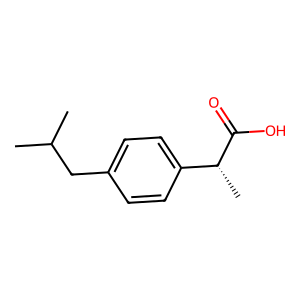

In [11]:
# Create a Molecule
# Ibuprofen

smiles = "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O"

mol = Chem.MolFromSmiles(smiles)

Draw.MolToImage(mol)

This is the normal 2D structure.

In [12]:
# Add Hydregens before generating 3D conformers
# Rdkit generates better 3D geometries when explicit hydrogens atoms are present.

mol = Chem.AddHs(mol)



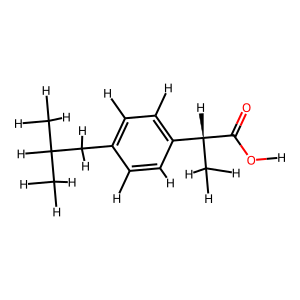

In [13]:
Draw.MolToImage(mol)

In [14]:
# Generate the 3D conformer

AllChem.EmbedMolecule(mol)

0

In [15]:
# Optimize the Geometry

AllChem.MMFFOptimizeMolecule(mol)

0

In [16]:
# Check the Number of Conformers

print("Number of conformers:", mol.GetNumConformers())

Number of conformers: 1


In [17]:
# Examine Atomic Coordinates

conf = mol.GetConformer()

for atom in mol.GetAtoms():

    pos = conf.GetAtomPosition(atom.GetIdx())

    print(
        atom.GetSymbol(),
        round(pos.x,2),
        round(pos.y,2),
        round(pos.z,2)
    )

C -4.64 -0.59 0.57
C -3.25 -0.05 0.24
C -3.09 1.35 0.84
C -2.18 -1.02 0.76
C -0.78 -0.68 0.3
C 0.16 -0.16 1.2
C 1.45 0.16 0.77
C 1.84 -0.04 -0.56
C 0.9 -0.58 -1.45
C -0.39 -0.89 -1.03
C 3.24 0.29 -1.04
C 3.53 1.79 -0.92
C 4.29 -0.51 -0.31
O 4.9 -0.2 0.7
O 4.53 -1.71 -0.89
H -5.42 0.07 0.19
H -4.79 -0.69 1.65
H -4.79 -1.58 0.11
H -3.18 0.04 -0.85
H -2.14 1.81 0.54
H -3.13 1.32 1.94
H -3.9 2.01 0.49
H -2.21 -1.07 1.86
H -2.4 -2.04 0.42
H -0.11 0.02 2.24
H 2.16 0.57 1.5
H 1.17 -0.76 -2.49
H -1.1 -1.31 -1.74
H 3.33 0.05 -2.11
H 2.8 2.38 -1.48
H 4.53 2.02 -1.31
H 3.51 2.13 0.12
H 5.19 -2.13 -0.3


In [9]:
# Save as an SDF File

writer = Chem.SDWriter("ibuprofen_3D.sdf")

writer.write(mol)

writer.close()

# This Create a 3D SDF file.

## Interpretation

A 3D conformer of Ibuprofen was successfully generated.

The process involved:

- Converting the SMILES into an RDKit molecule.
- Adding explicit hydrogen atoms.
- Embedding the molecule into three-dimensional space.
- Optimizing the geometry using the MMFF force field.

The resulting conformer contains 3D atomic coordinates that can be used for downstream applications such as molecular docking, pharmacophore modeling, shape comparison, and 3D QSAR

In [9]:
# Import Libraries

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
import py3Dmol

# save the optimized conformer

In [18]:
Chem.MolToMolFile(mol, "ibuprofen_3D.mol")

# Read the MOl file

In [19]:
with open("ibuprofen_3D.mol", "r") as f:
    mol_block = f.read()

# Create the 3D viewer

In [24]:
# Ball- and Stick representation

In [20]:
import py3Dmol

view = py3Dmol.view(width=600, height=450)

view.addModel(mol_block, "mol")

view.setStyle({"stick": {}})

view.zoomTo()

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [25]:
# # Ball- and Stick representation

In [21]:
view = py3Dmol.view(width=600, height=450)

view.addModel(mol_block, "mol")

view.setStyle({"stick": {}, "sphere": {"scale": 0.3}})

view.zoomTo()

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [26]:
# Cartoon colors (CPK)

In [22]:
view = py3Dmol.view(width=600, height=450)

view.addModel(mol_block, "mol")

view.setStyle({"stick": {"colorscheme": "Jmol"}})

view.zoomTo()

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [23]:
view = py3Dmol.view(width=600, height=450)

view.setBackgroundColor("white")

view.addModel(mol_block, "mol")

view.setStyle({"stick": {"colorscheme": "Jmol"}})

view.zoomTo()

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The optimized Ibuprofen conformer was visualized in three-dimensional space using py3Dmol. Unlike a 2D structure, the 3D conformer reveals the actual spatial arrangement of atoms after energy minimization. Such conformers are essential for applications including molecular docking, pharmacophore modeling, shape comparison, and 3D QSAR studies.